# `playlistsmith` — Vignette

**Content-based playlist clustering from an Exportify CSV.**

Spotify's `/audio-features` and `/recommendations` endpoints were deprecated for new
applications in November 2024. `playlistsmith` fills that gap by sourcing audio features
from [ReccoBeats](https://reccobeats.com), then clustering the resulting feature matrix
so a user can re-organise their library into content-similar playlists.

This notebook walks the package top-to-bottom: *what problem, who for, how
it looks, how it flows, how it's built, then run it and see results.*

Sections marked **(future work)** describe planned components that are not yet wired up;
everything else is exercised by the live cells below.

## 1. Scenario — who uses this and how

**Purpose.** Describe how a typical user goes from an exported Spotify CSV to a folder
of clustered playlists.

**Individual user.** A hobbyist with a 500–2000-track Spotify library, comfortable with
Python and a terminal but not a developer. They want playlists that are more
content-coherent than Spotify's auto-mixes.

**Equipment / assumptions.**

- Python 3.12 (pinned in [pyproject.toml](../pyproject.toml)).
- Dependencies: numpy, pandas, scikit-learn, scipy, umap-learn, hdbscan, httpx (via
  [`_http.py`](../src/playlistsmith/_http.py)).
- Internet access for the ReccoBeats API (free, no key).
- A CSV produced by https://exportify.app. For this notebook we bundle
  [`docs/example_synthetic.csv`](./example_synthetic.csv) — a synthetic Exportify-
  shaped file with ~35 fake tracks — and mock the ReccoBeats API in the setup cell,
  so the vignette runs fully offline and ships no Spotify content.

**Scenario steps.**

1. Export your library from Spotify via Exportify, download the CSV.
2. Install the package from source: `pip install -e .`.
3. Run the pipeline (this notebook, or `python testing_pipeline.py`) pointed at the CSV.
4. Read the coverage report: how many tracks resolved, how many were dropped because
   ReccoBeats didn't know them.
5. Read per-cluster summaries (e.g. *"high energy, fast tempo, low valence"*) and a 2-D
   UMAP scatter coloured by cluster.
6. Inspect pipeline warnings (e.g. *"cluster 0 holds 60% of the library — try a larger
   k"*).
7. Re-run with a different `method` (`kmeans`, `hdbscan`) or a different `k_range` if
   the result is unsatisfying.
8. **(future work)** Export one CSV per cluster to a folder of playlists
   (`io.playlist_export.write_cluster_csvs`).

**Open questions (deliberately unresolved).**

- *What happens when the CSV has no Spotify IDs at all?* — Today: the loader raises
  `ValueError("No tracks with a Spotify track ID found ...")`.
- *Is `min_playlist_size=5` defensible for libraries of ~100 tracks?* — Probably not;
  see §5 step 7 below where we deliberately trip the resulting warning.

## 2. Screenshots / UI sketches — what the user sees

Per the brief, rough sketches are acceptable at this stage. The real UI today is the
notebook / CLI itself; the Streamlit GUI is planned in [`plans/gui.md`](../plans/gui.md)
but not yet built.

### 2a. Planned Streamlit GUI (mock-up, not implemented)

```
 +-----------------------------------------------------------+
 |  playlistsmith                                            |
 +-------------------+---------------------------------------+
 | [sidebar]         |  [main panel]                         |
 |                   |                                       |
 | 1. Upload CSV     |   step 1.  drag-and-drop CSV here     |
 | 2. Extract feats. |   step 2.  Extract  [run]             |
 | 3. Cluster        |             coverage: 412/500 tracks  |
 | 4. Visualise      |   step 3.  method [gmm v]   k 2..12   |
 | 5. Export         |             [cluster]                 |
 |                   |   step 4.  <3-D Plotly scatter>       |
 |                   |   step 5.  rename clusters, [export]  |
 +-------------------+---------------------------------------+
```

### 2b. Actual current UI: notebook / CLI

The code cells below are the *real* current UI. The captioned outputs in §5 (coverage
report, BIC curve, per-cluster summaries, z-profile heatmap, UMAP scatter) are what a
user actually sees when they run the pipeline today.

## 3. Flowchart — user actions vs software actions

```mermaid
flowchart TB
  subgraph User
    U1[Export library via Exportify]
    U2[Drop CSV into notebook / CLI]
    U3[Choose method + k_range, run cluster]
    U4[Inspect summaries, warnings, scatter]
    U5[Rename clusters, export -- future]
  end
  subgraph Software
    S1[TrackLibrary._load]
    S2[features.extract -- ReccoBeats lookup]
    S3{tracks resolved == 0?}
    S4[cluster.preprocess.prepare_matrix]
    S5[fit_gmm / fit_kmeans / fit_hdbscan]
    S6[_canonical_order]
    S7[_collapse_small_clusters]
    S8{any cluster > max_playlist_share?}
    S9[describe_clusters + _build_diagnostics]
    S10[io.playlist_export -- future]
  end
  U1 --> U2 --> S1 --> S2 --> S3
  S3 -- yes --> X[Abort with coverage message]
  S3 -- no --> U3 --> S4 --> S5 --> S6 --> S7 --> S8
  S8 -- yes --> W[Emit dominant-cluster warning]
  S8 -- no  --> S9 --> U4 --> U5 --> S10
```

Decision points the flowchart highlights:

- *Tracks resolved == 0?* → abort with the coverage message.
- *Cluster larger than `max_playlist_share`?* → emit a warning (no auto-split).
- *Cluster smaller than `min_playlist_size`?* → collapse into Unclassified (cluster `-1`).

## 4. Design — architecture of the project

### 4a. Public interfaces — input / output

| Entry point | Input | Output |
|---|---|---|
| `TrackLibrary(csv_path)` | path to an Exportify CSV | `tlib.dataframe` with `[title, artist, spotify_id]` |
| `tlib.extract_features(mode="precomputed")` | the library | `(features_df, CoverageReport)` |
| `ps.cluster(features_df, method, k_range, ...)` | the features frame | `ClusterPipelineResult` (tracks, descriptions, clustering, transform_log, diagnostics, warnings) |

### 4b. Internal vs external representations

- **In memory:** dataclasses (`ClusteringResult`, `ClusterPipelineResult`,
  `ClusterDiagnostics`, `TransformLog`, `CoverageReport`) and pandas DataFrames.
- **On disk:** CSV in, CSV out. No database; cache TTL bounded per
  [`CLAUDE.md`](../CLAUDE.md).

### 4c. Procedure chain (the order in which things run)

```
csv_loader.TrackLibrary._load
  -> features.reccobeats._resolve_spotify_ids
  -> features.reccobeats._fetch_audio_features
  -> cluster.preprocess.prepare_matrix
  -> cluster.algorithms.fit_{gmm,kmeans,hdbscan}
  -> cluster.public._canonical_order
  -> cluster.public._collapse_small_clusters
  -> cluster.interpret.describe_clusters
  -> cluster.public._build_diagnostics
  -> (future) io.playlist_export.write_cluster_csvs
```

### 4d. Non-negotiables (from `CLAUDE.md`)

- No Spotify-derived features in the ML pipeline. ReccoBeats only.
- Single `features.extract(mode=...)` entry point; no parallel pipelines.
- Shared HTTP client in [`_http.py`](../src/playlistsmith/_http.py); never
  `httpx.get(...)` directly.
- GMM preferred over KMeans; BIC for selection; silhouette + cohesion reported alongside.

## 5. Example application — run it and look at the output

Everything above is framing. This section is the meat of the vignette: end-to-end
the pipeline on a synthetic Exportify CSV, with ReccoBeats mocked so the notebook
runs offline and ships no third-party content. We show the figures, and deliberately
trip a warning to validate the error-message contract.

### Setup

To keep the vignette fully offline and free of any third-party content, we ship a
**synthetic Exportify-shaped CSV** ([`docs/example_synthetic.csv`](./example_synthetic.csv))
with ~35 fake tracks whose IDs encode three latent clusters, and we **mock the
ReccoBeats API** by installing an `httpx.MockTransport` on the shared HTTP client.
The mock returns deterministic synthetic features per ID drawn from three cluster
centres plus Gaussian noise, with a handful of IDs deliberately unknown so the
`CoverageReport.dropped_tracks` failure mode has something to show.

Why this shape:

- Exercises the *real* `playlistsmith.features.reccobeats` code path end-to-end
  (batching, the `href` → Spotify-ID recovery, `CoverageReport`).
- Zero Spotify content anywhere — file, repo, or runtime.
- Deterministic and sub-second. All clustering cells pass `random_state=0`.
- Same pattern as the existing `pytest-httpx` tests, wrapped in notebook cells.

The bootstrap cell below installs the package + plotting libraries; the mock cell
after it wires up the offline ReccoBeats stub before any feature call happens.

In [15]:
# Bootstrap: install playlistsmith (from the repo root, one level above this notebook)
# plus the plotting libraries this notebook uses but the package itself does not depend on.
import importlib
import subprocess
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent

def _pip_install(*args: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *args])

if importlib.util.find_spec("playlistsmith") is None:
    _pip_install("-e", str(REPO_ROOT))

missing = [pkg for pkg in ("matplotlib", "seaborn") if importlib.util.find_spec(pkg) is None]
if missing:
    _pip_install(*missing)

print("Python:   ", sys.version.split()[0])
print("Repo root:", REPO_ROOT)

Python:    3.12.7
Repo root: /Users/julian/Documents/playlistsmith


In [16]:
# Mock ReccoBeats: intercept both endpoints used by playlistsmith.features.reccobeats
# and return deterministic synthetic features. The Spotify IDs in example_synthetic.csv
# encode their target cluster in the 4th character ('A' / 'B' / 'C'); 'X' is reserved
# for IDs the mock pretends not to know, so dropped_tracks has something to show.
import hashlib
import json

import httpx
import numpy as np

from playlistsmith import _http
from playlistsmith.features.reccobeats import FEATURE_COLUMNS

# Cluster centres in raw ReccoBeats feature space. Loudness is in dB; tempo in BPM;
# every other feature lives on [0, 1]. Chosen so the three clusters are clearly
# separable but not trivially so.
_CLUSTER_CENTRES = {
    "A": {  # chill / acoustic
        "acousticness": 0.80, "danceability": 0.40, "energy": 0.20,
        "instrumentalness": 0.10, "liveness": 0.10, "loudness": -18.0,
        "speechiness": 0.05, "tempo": 85.0, "valence": 0.55,
    },
    "B": {  # upbeat / dance
        "acousticness": 0.15, "danceability": 0.80, "energy": 0.75,
        "instrumentalness": 0.05, "liveness": 0.15, "loudness": -6.0,
        "speechiness": 0.08, "tempo": 120.0, "valence": 0.75,
    },
    "C": {  # intense / electronic
        "acousticness": 0.05, "danceability": 0.55, "energy": 0.92,
        "instrumentalness": 0.50, "liveness": 0.20, "loudness": -4.0,
        "speechiness": 0.06, "tempo": 150.0, "valence": 0.30,
    },
}
# Per-feature jitter scales (1 sigma). loudness/tempo on their natural scales,
# everything else small enough to keep features in [0, 1] after a clip.
_JITTER = {
    "acousticness": 0.05, "danceability": 0.05, "energy": 0.05,
    "instrumentalness": 0.05, "liveness": 0.04, "loudness": 1.5,
    "speechiness": 0.02, "tempo": 4.0, "valence": 0.05,
}

def _features_for(spotify_id: str) -> dict[str, float] | None:
    """Synthetic ReccoBeats features for one ID; None for unknown ('X') IDs."""
    # ID layout: 'syn<letter><18 digits>'. Anything else: pretend unknown.
    if len(spotify_id) < 4 or not spotify_id.startswith("syn"):
        return None
    cluster_letter = spotify_id[3]
    if cluster_letter not in _CLUSTER_CENTRES:
        return None
    centre = _CLUSTER_CENTRES[cluster_letter]
    # Per-ID deterministic seed -> reproducible noise.
    seed = int(hashlib.sha1(spotify_id.encode()).hexdigest()[:8], 16)
    rng = np.random.default_rng(seed)
    out: dict[str, float] = {}
    for col in FEATURE_COLUMNS:
        val = float(centre[col] + rng.normal(0.0, _JITTER[col]))
        if col in {"acousticness", "danceability", "energy", "instrumentalness",
                   "liveness", "speechiness", "valence"}:
            val = float(np.clip(val, 0.0, 1.0))
        out[col] = val
    return out

def _handle(request: httpx.Request) -> httpx.Response:
    """MockTransport handler for ReccoBeats /v1/track and /v1/audio-features."""
    ids = [s for s in request.url.params.get("ids", "").split(",") if s]
    if request.url.path == "/v1/track":
        # The real API maps Spotify IDs to ReccoBeats internal IDs; the client
        # recovers the Spotify ID from the returned href. We mirror that
        # contract: 'rb-<spotify_id>' is our fake ReccoBeats ID, the href
        # carries the original Spotify ID back.
        content = [
            {"id": f"rb-{sid}", "href": f"https://open.spotify.com/track/{sid}"}
            for sid in ids
            if _features_for(sid) is not None
        ]
        return httpx.Response(200, json={"content": content})
    if request.url.path == "/v1/audio-features":
        content = []
        for rb_id in ids:
            # Recover Spotify ID from our 'rb-<sid>' convention.
            if not rb_id.startswith("rb-"):
                continue
            sid = rb_id[3:]
            feats = _features_for(sid)
            if feats is None:
                continue
            content.append({"id": rb_id, **feats})
        return httpx.Response(200, json={"content": content})
    return httpx.Response(404, json={"content": []})

# Install the mock on the shared client. Reset the singleton so any prior
# real-network client (e.g. from a previous notebook run in the same kernel)
# is dropped.
_http._client = httpx.Client(
    transport=httpx.MockTransport(_handle),
    headers={"User-Agent": "playlistsmith-vignette/mock"},
)
print("Mock ReccoBeats transport installed. Known cluster letters:",
      list(_CLUSTER_CENTRES))

Mock ReccoBeats transport installed. Known cluster letters: ['A', 'B', 'C']


In [32]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import playlistsmith as ps

# Path is relative to this notebook. The synthetic CSV sits next to the notebook
# in docs/, so a single ``Path().resolve()`` works regardless of where Jupyter
# was launched from.
CSV_PATH = Path().resolve() / "example_synthetic.csv"

### Step 1 — load the library

`TrackLibrary` parses an Exportify (`;`-delimited) CSV down to the three identity
columns the rest of the pipeline cares about: `title`, `artist`, `spotify_id`. Rows
with no Spotify track ID are dropped at load time.

In [33]:
tlib = ps.TrackLibrary(CSV_PATH)
print(tlib)
tlib.dataframe.head()

TrackLibrary(source_path='/Users/julian/Documents/playlistsmith/docs/example_synthetic.csv', tracks=35)


,title,artist,spotify_id
0,Drift,The Placeholders,synA000000000000000001
1,Quiet Tide,Sample Collective,synA000000000000000002
2,Window Light,Lorem Beats,synA000000000000000003
3,Slow Rain,Stub Choir,synA000000000000000004
4,Almost Morning,Fixture Six,synA000000000000000005


### Step 2 — extract features (ReccoBeats lookup)

`extract_features(mode="precomputed")` calls the single public
`playlistsmith.features.extract` entry point, which in turn batches Spotify IDs through
ReccoBeats' `/v1/track` + `/v1/audio-features` endpoints via the shared HTTP client.
Anything ReccoBeats does not know is dropped and reported on the
[`CoverageReport`](../src/playlistsmith/features/__init__.py) — the failure mode is
always visible.

In [34]:
features, coverage = tlib.extract_features(mode="precomputed")
print(coverage.render())
print(f"Feature frame: {len(features)} resolved track(s), columns = {list(features.columns)}")
features.head()

[playlistsmith] Dropped 3 track(s) with no ReccoBeats precomputed features:
  - Test Phantom — Unknown Provider
  - Missing Index — Off-Catalogue Trio
  - Null Wave — Unknown Provider
Feature coverage: 32/35 track(s) resolved via ReccoBeats; 3 dropped.
Feature frame: 32 resolved track(s), columns = ['spotify_id', 'title', 'artist', 'acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']


,spotify_id,title,artist,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
0,synA000000000000000001,Drift,The Placeholders,0.846194,0.378767,0.176992,0.044003,0.065825,-18.246503,0.022890,82.337549,0.533509
1,synA000000000000000002,Quiet Tide,Sample Collective,0.833947,0.420571,0.080317,0.124211,0.099663,-16.861440,0.036802,81.772230,0.536931
2,synA000000000000000003,Window Light,Lorem Beats,0.740880,0.355191,0.212117,0.134979,0.104113,-18.292988,0.069700,84.943855,0.666672
3,synA000000000000000004,Slow Rain,Stub Choir,0.824493,0.312121,0.268582,0.000377,0.058100,-18.864513,0.054049,77.805910,0.628330
4,synA000000000000000005,Almost Morning,Fixture Six,0.867695,0.417158,0.170849,0.163886,0.108118,-17.731240,0.046659,85.080817,0.460346


In [20]:
# Surface the dropped tracks so the user can see exactly which ones ReccoBeats missed.
coverage.dropped_tracks

,spotify_id,title,artist
0,synX000000000000000001,Test Phantom,Unknown Provider
1,synX000000000000000002,Missing Index,Off-Catalogue Trio
2,synX000000000000000003,Null Wave,Unknown Provider


### Step 3 — cluster with the default (GMM)

`ps.cluster(...)` wraps preprocessing (logit/log transforms, median imputation,
scaling), the GMM fit with BIC/ICL model selection, the canonical cluster ordering
(cluster 0 is the largest, ties broken by PC1) and the small-cluster collapse into
Unclassified (`-1`).

`example_exportify.csv` is tiny (a handful of tracks) so we pass a small `k_range` and
loosen `min_playlist_size=1`; the step 7 cell below shows what happens when those
knobs are wrong for the library.

In [21]:
result = ps.cluster(
    features,
    method="gmm",
    random_state=0,
    k_range=range(2, min(5, max(3, len(features)))),
    min_playlist_size=1,
)

summary = {
    "method": f"GMM ({result.clustering.covariance_type} covariance)",
    "k chosen": result.clustering.k,
    "silhouette": round(result.clustering.silhouette, 3),
    "cohesion": round(result.clustering.cohesion, 3),
    "stability_ari": round(result.clustering.stability_ari, 3),
}
summary

{'method': 'GMM (diag covariance)',
 'k chosen': 4,
 'silhouette': 0.509,
 'cohesion': 1.748,
 'stability_ari': 1.0}

BIC curve: {2: 612.2, 3: 411.4, 4: 398.0}
ICL curve: {2: 612.2, 3: 411.4, 4: 398.0}


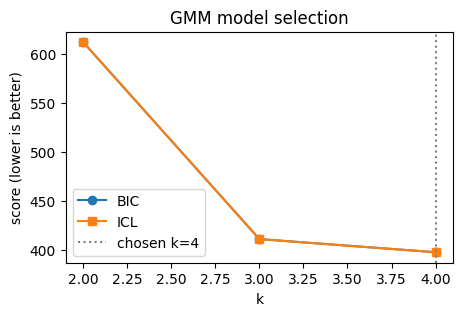

In [22]:
# Model-selection curves: BIC (used for selection) + ICL (reported alongside).
bic = {k: round(v, 1) for k, v in result.clustering.bic_curve.items()}
icl = {k: round(v, 1) for k, v in result.clustering.icl_curve.items()}
print("BIC curve:", bic)
print("ICL curve:", icl)

if len(bic) >= 2:
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(list(bic.keys()), list(bic.values()), marker="o", label="BIC")
    ax.plot(list(icl.keys()), list(icl.values()), marker="s", label="ICL")
    ax.axvline(result.clustering.k, color="grey", linestyle=":", label=f"chosen k={result.clustering.k}")
    ax.set_xlabel("k")
    ax.set_ylabel("score (lower is better)")
    ax.set_title("GMM model selection")
    ax.legend()
    plt.show()

In [23]:
# Preprocessing log: which columns were logit/log-transformed, how many cells
# imputed, which tracks dropped because too many features were missing.
log = result.transform_log
print("logit columns:", list(log.logit_columns))
print("log columns:  ", list(log.log_columns))
print("imputed cells:", log.imputed_counts)
print("dropped tracks (>3 NaN of 9):", len(log.dropped_tracks))
log.dropped_tracks

logit columns: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'valence']
log columns:   ['tempo']
imputed cells: {}
dropped tracks (>3 NaN of 9): 0


,spotify_id,title,artist


### Step 4 — interpret

`describe_clusters` produces one row per cluster with the top-discriminating features
and a short human-readable `cluster_summary` string (the thing a playlist gets named
after).

In [24]:
result.descriptions[["cluster", "size", "top_features", "cluster_summary"]]

,cluster,size,top_features,cluster_summary
0,0,12,"[danceability, speechiness]","high danceability, high speechiness"
1,1,10,"[loudness, liveness, speechiness]","quiet, low liveness, low speechiness"
2,2,8,"[valence, acousticness]","low valence, low acousticness"
3,3,2,"[instrumentalness, loudness, liveness]","low instrumentalness, quiet, low liveness"


In [25]:
# Per-track output: this is what io.playlist_export will eventually slice into
# one CSV per cluster.
result.tracks.head(10)

,spotify_id,title,artist,cluster,cluster_summary
0,synA000000000000000001,Drift,The Placeholders,1,"quiet, low liveness, low speechiness"
1,synA000000000000000002,Quiet Tide,Sample Collective,1,"quiet, low liveness, low speechiness"
2,synA000000000000000003,Window Light,Lorem Beats,1,"quiet, low liveness, low speechiness"
3,synA000000000000000004,Slow Rain,Stub Choir,3,"low instrumentalness, quiet, low liveness"
4,synA000000000000000005,Almost Morning,Fixture Six,1,"quiet, low liveness, low speechiness"
5,synA000000000000000006,Vellum,Yield Returns,1,"quiet, low liveness, low speechiness"
6,synA000000000000000007,Hush Field,Mock Anthem,1,"quiet, low liveness, low speechiness"
7,synA000000000000000008,Paper Lantern,Synthetic Sunrise,1,"quiet, low liveness, low speechiness"
8,synA000000000000000009,First Frost,"Test Signal, Dummy Vox",1,"quiet, low liveness, low speechiness"
9,synA000000000000000010,Linen,The Placeholders,1,"quiet, low liveness, low speechiness"


### Step 5 — visualise

`ClusterDiagnostics` carries everything the (future) viz subpackage needs without the
cluster step itself importing a plotting library. Here we plot three things directly:

1. **z-profile heatmap** — rows = clusters, columns = the nine ReccoBeats features.
   Tells you what each cluster is *about*.
2. **2-D UMAP scatter** — coloured by cluster, with Unclassified (`-1`) in grey.
3. **PCA explained-variance bar** — how much structure lives in the first few axes.

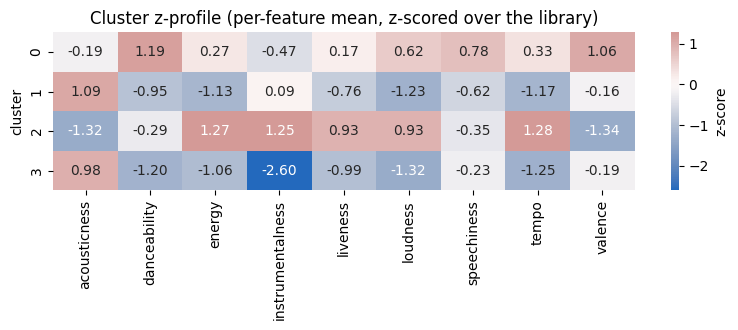

In [26]:
diag = result.diagnostics

fig, ax = plt.subplots(figsize=(8, max(2, 0.6 * len(diag.zprofile_heatmap) + 1)))
sns.heatmap(
    diag.zprofile_heatmap,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="vlag",
    cbar_kws={"label": "z-score"},
    ax=ax,
)
ax.set_title("Cluster z-profile (per-feature mean, z-scored over the library)")
ax.set_ylabel("cluster")
plt.tight_layout()
plt.show()

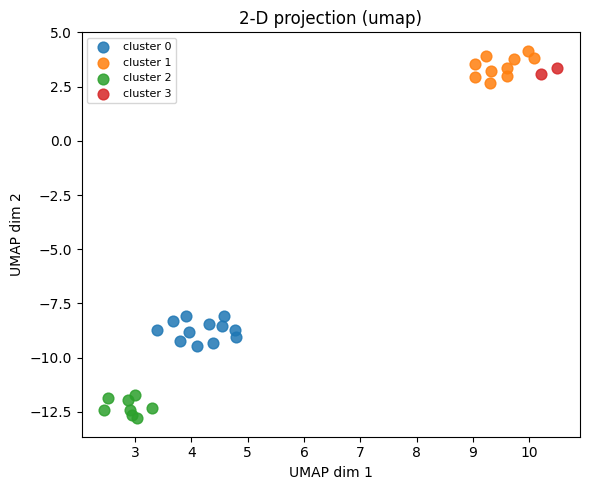

In [27]:
proj = diag.projection_2d.copy()
proj["cluster"] = result.tracks["cluster"].to_numpy()

fig, ax = plt.subplots(figsize=(6, 5))
for cid, sub in proj.groupby("cluster"):
    colour = "#999999" if cid == -1 else None
    label = "Unclassified" if cid == -1 else f"cluster {cid}"
    ax.scatter(sub["dim1"], sub["dim2"], label=label, color=colour, s=60, alpha=0.85)
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_title(f"2-D projection ({diag.projection_method})")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

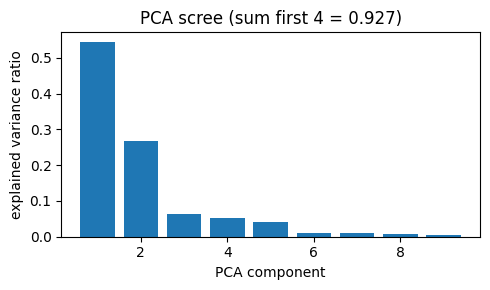

In [28]:
ev = diag.pca_explained_variance_ratio
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(1, len(ev) + 1), ev)
ax.set_xlabel("PCA component")
ax.set_ylabel("explained variance ratio")
ax.set_title(f"PCA scree (sum first 4 = {sum(ev[:4]):.3f})")
plt.tight_layout()
plt.show()

### Step 6 — alternative methods (K-Means, HDBSCAN)

Re-running with the two other implemented methods makes the design decision *"GMM
preferred; KMeans/HDBSCAN available for hard/density needs"* observable rather than
just stated. Watch how the per-cluster summaries and quality metrics differ.

In [29]:
kmeans_result = ps.cluster(
    features,
    method="kmeans",
    random_state=0,
    k_range=range(2, min(5, max(3, len(features)))),
    min_playlist_size=1,
)
print(f"k chosen   : {kmeans_result.clustering.k}")
print(f"silhouette : {kmeans_result.clustering.silhouette:.3f}")
print("inertia    :", {k: round(v, 1) for k, v in kmeans_result.clustering.inertia_curve.items()})
print("CH         :", {k: round(v, 1) for k, v in kmeans_result.clustering.calinski_harabasz_curve.items()})
kmeans_result.descriptions[["cluster", "size", "cluster_summary"]]

k chosen   : 3
silhouette : 0.547
inertia    : {2: 145.4, 3: 68.5, 4: 55.9}
CH         : {2: 29.4, 3: 46.5, 4: 38.7}


,cluster,size,cluster_summary
0,0,12,"quiet, low liveness, low speechiness"
1,1,12,"high danceability, high speechiness"
2,2,8,"low valence, low acousticness"


In [30]:
hdb_result = ps.cluster(
    features,
    method="hdbscan",
    random_state=0,
    min_playlist_size=1,
    hdbscan_min_cluster_size=2,
)
print(f"discovered clusters    : {hdb_result.clustering.k}")
print(f"noise rate             : {hdb_result.clustering.noise_rate:.1%}")
print(f"silhouette (non-noise) : {hdb_result.clustering.silhouette:.3f}")
hdb_result.descriptions[["cluster", "size", "cluster_summary"]]

discovered clusters    : 4
noise rate             : 0.0%
silhouette (non-noise) : 0.509


,cluster,size,cluster_summary
0,0,12,"high danceability, high speechiness"
1,1,10,"quiet, low liveness, low speechiness"
2,2,8,"low valence, low acousticness"
3,3,2,"low instrumentalness, quiet, low liveness"


GMM gives soft posteriors and BIC-selected `k`; KMeans gives a hard partition with
silhouette + Calinski–Harabasz; HDBSCAN sidesteps `k` entirely and flushes outliers into
cluster `-1`. They are not interchangeable — the framework just makes them comparable
side-by-side on the same feature frame.

### Step 7 — warnings & failure modes

Deliberately set `min_playlist_size` larger than the library so the collapse step routes
every track to Unclassified. The error-message contract says the warning must *name the
public knob* and *suggest a fix* — we expect to see `min_playlist_size`, `k_range`, and
`method` all mentioned in the surfaced warning.

In [31]:
tripped = ps.cluster(
    features,
    method="gmm",
    random_state=0,
    k_range=range(2, min(5, max(3, len(features)))),
    min_playlist_size=len(features) + 1,  # nothing can survive
)
for w in tripped.warnings:
    print("-", w)
print()
tripped.descriptions

- All 32 tracks landed in the Unclassified bucket — no playlists were produced. Consider lowering min_playlist_size (currently 33), passing a smaller k_range, or trying method='hdbscan' with a smaller min_cluster_size.



,cluster,size,top_features,z_profile,cluster_summary
0,-1,32,[],{},unclassified


### Step 8 — export (future work)

`io.playlist_export.write_cluster_csvs(result.tracks, out_dir)` will eventually slice
`result.tracks` into one CSV per cluster id (with `-1` written as `Unclassified.csv`),
and emit a manifest. The cluster IDs and per-track summaries needed for that step are
already in `result.tracks` today — only the writer is missing.

Sketch of the eventual call:

```python
from playlistsmith.io import playlist_export  # future
playlist_export.write_cluster_csvs(result.tracks, out_dir="./playlists/")
```

## 6. Wrap-up

This vignette walked the implemented path end-to-end: Exportify CSV → `TrackLibrary` →
ReccoBeats lookup → preprocessing → clustering (GMM / KMeans / HDBSCAN) → canonical
ordering and small-cluster collapse → per-cluster interpretation → diagnostics (PCA,
UMAP, z-profile heatmap). The two pieces still scaffolded are the Streamlit GUI
([`plans/gui.md`](../plans/gui.md)) and the playlist CSV writer
(`io.playlist_export`); both consume artefacts that already exist on
`ClusterPipelineResult`.

### How to reproduce

```bash
# from the repo root
pip install -e .
jupyter lab docs/vignette.ipynb
```

Python 3.12, pinned in `pyproject.toml`. Internet access is required for ReccoBeats
unless HTTP is mocked (see the `pytest-httpx` fixtures under [`tests/`](../tests/) for
the pattern).